In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import pickle
from scipy.stats import multivariate_normal as mn
from scipy.stats import norm

In [2]:
def to_day(di):
    if di >= 2:
        return "Day6"
    else:
        return "Day" + str(di + 1)

In [3]:
with open('beh.pkl', 'rb') as f:
    beh = pickle.load(f)
with open("h_spike.pkl", "rb") as f:
    h = pickle.load(f)
with open("maze.pkl", "rb") as f:
    maze = pickle.load(f)

In [4]:
maze2 = np.unique(maze//2, axis=0).astype(int)

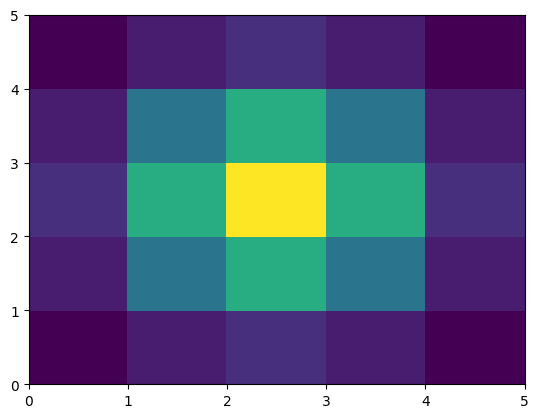

In [5]:
m = [0, 0]
c = [[4, 0], [0, 4]]
filt = np.zeros((5, 5))
for i in range(3):
    for j in range(i+1):
        val = mn.cdf([1+2*i, 1+2*j], mean=m, cov=c) - mn.cdf([1+2*i, -1+2*j], mean=m, cov=c) - mn.cdf([-1+2*i, 1+2*j], mean=m, cov=c) + mn.cdf([-1+2*i, -1+2*j], mean=m, cov=c)
        filt[2+i, 2+j] = val
        filt[2+j, 2+i] = val
        filt[2-i, 2+j] = val
        filt[2-j, 2+i] = val
        filt[2+i, 2-j] = val
        filt[2+j, 2-i] = val
        filt[2-i, 2-j] = val
        filt[2-j, 2-i] = val
filt /= filt.sum()
plt.pcolor(filt)

In [6]:
n_maze = maze2.shape[0]
maze2_recon = pd.DataFrame(maze2).sort_values([1, 0]).values
maze2_notna = np.zeros((20, 20), dtype=bool)
for xi, yi in maze2:
    maze2_notna[yi, xi] = True

In [7]:
loc_vecs = []
for mi in range(6):
    loc_vecs_s = []
    for di in range(3):
        print("Processing Mouse ID: {}, {}".format(mi + 1, to_day(di)))
        k = h[mi][di].shape[1]
        t = beh[mi][di].shape[0]
        index = beh[mi][di][:, 5:] // 2
        
        tmp_vec = np.zeros((k, 50, n_maze))
        for i in range(50):
            grob_mean = h[mi][di][49-i:49+t-i, :].mean(axis=0)
            grob_std = h[mi][di][49-i:49+t-i, :].std(axis=0)
            
            df = pd.DataFrame(np.hstack((index, h[mi][di][49-i:49+t-i, :]))).groupby([0, 1])
            df_sum = df.sum()
            df_count = df.count().values[:, 0]
        
            tmp_sum = np.empty((20, 20, k))
            tmp_count = np.empty((20, 20))
            tmp_sum[:, :, :] = np.nan
            tmp_count[:, :] = np.nan
        
            for ind, (val_sum, val_count) in zip(df_sum.index, zip(df_sum.values, df_count)):
                tmp_sum[int(ind[1]), int(ind[0]), :] = val_sum
                tmp_count[int(ind[1]), int(ind[0])] = val_count
                          
            ret_sum = np.zeros_like(tmp_sum)
            ret_count = np.zeros_like(tmp_count)
            for xi, yi in maze2:
                mxi, mxj, myi, myj = max(0, xi-2), min(20, xi+3), max(0, yi-2), min(20, yi+3)
                fxi, fxj, fyi, fyj = max(0, 2-xi), min(5, 22-xi), max(0, 2-yi), min(5, 22-yi)
                not_nan = ~np.isnan(tmp_count[myi:myj, mxi:mxj])
                filtered_sum = tmp_sum[myi:myj, mxi:mxj, :] * filt[fyi:fyj, fxi:fxj, np.newaxis]
                filtered_count = tmp_count[myi:myj, mxi:mxj] * filt[fyi:fyj, fxi:fxj]
                den = filt[fyi:fyj, fxi:fxj][not_nan].sum()
                ret_sum[yi, xi, :] = filtered_sum[not_nan].sum(axis=0) / den
                ret_count[yi, xi] = filtered_count[not_nan].sum() / den
                              
            vec_sum = ret_sum[maze2_notna]
            vec_count = ret_count[maze2_notna]
            ind = vec_count > 0
            
            tmp_vec[:, i, ind] = (vec_sum[ind, :] / vec_count[ind, np.newaxis]).T
        loc_vecs_s.append(tmp_vec)
    loc_vecs.append(loc_vecs_s)

Processing Mouse ID: 1, Day1
Processing Mouse ID: 1, Day2
Processing Mouse ID: 1, Day6
Processing Mouse ID: 2, Day1
Processing Mouse ID: 2, Day2
Processing Mouse ID: 2, Day6
Processing Mouse ID: 3, Day1
Processing Mouse ID: 3, Day2
Processing Mouse ID: 3, Day6
Processing Mouse ID: 4, Day1
Processing Mouse ID: 4, Day2
Processing Mouse ID: 4, Day6
Processing Mouse ID: 5, Day1
Processing Mouse ID: 5, Day2
Processing Mouse ID: 5, Day6
Processing Mouse ID: 6, Day1
Processing Mouse ID: 6, Day2
Processing Mouse ID: 6, Day6


In [8]:
inv_index = np.hstack([np.where(19 - maze2_recon[:, 1] == i)[0] for i in range(20)])
loc_vecs_inv = [[loc_vecs[mi][di][:, :, inv_index] for di in range(3)] for mi in range(6)]

In [9]:
with open("maze2.pkl", "wb") as f:
    pickle.dump(maze2, f)
with open("maze2_recon.pkl", "wb") as f:
    pickle.dump(maze2_recon, f)
with open("loc_vecs.pkl", "wb") as f:
    pickle.dump(loc_vecs, f)
with open("loc_vecs_inv.pkl", "wb") as f:
    pickle.dump(loc_vecs_inv, f)